In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('seaborn-v0_8-dark')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (16, 9),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import QuantLib as ql
import rateslib as rl

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC")

import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

In [2]:
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP, _alias_to_cusip
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP

from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondStructure import FixedRateBondStructure, FixedRateBondStructureFunctionMap
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue, FixedRateBondValueFunctionMap

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

from Query.STIRFutures.STIRFutureQuery import STIRFutureQuery
from Query.STIRFutures.STIRFutureStructure import STIRFutureStructure
from Query.STIRFutures.STIRFutureValue import STIRFutureValue


from TB.FixedRateBondsTB import FixedRateBondsTB
from TB.IRSwapsTB import IRSwapsTB
from TB.TimeseriesBuilder import TimeseriesBuilder

from RVUtils.Interpolation.GeneralCurveInterpolator import GeneralCurveInterpolator
from RVUtils.ust_viz import plot_usts, plot_usts_comparison
from RVUtils.plt_timeseries import make_secondary_axis_plot

from BT.data_handler import TimeGrid
from BT.misc import ql_cal_date_range
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import DateTrigger, DateTriggerRequirements

In [3]:
usts_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-QL")
swaps_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")
stir_mdp = STIRFutureMDP(source="BARCHART_STIRF-RL")

# swaps_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-QL_BASIC")
# tb = TimeseriesBuilder(
#     irswaps_tb=IRSwapsTB(swaps_mdp),
#     fixedratebonds_tb=FixedRateBondsTB(usts_mdp),
# )

BACKTESTING...: 100%|██████████| 11/11 [00:00<00:00, 111.64step/s]

100 None
2500.0
2500.0
2500.0
2500.0
2500.0
2500.0
2500.0
2500.0
2500.0
2500.0
2500.0


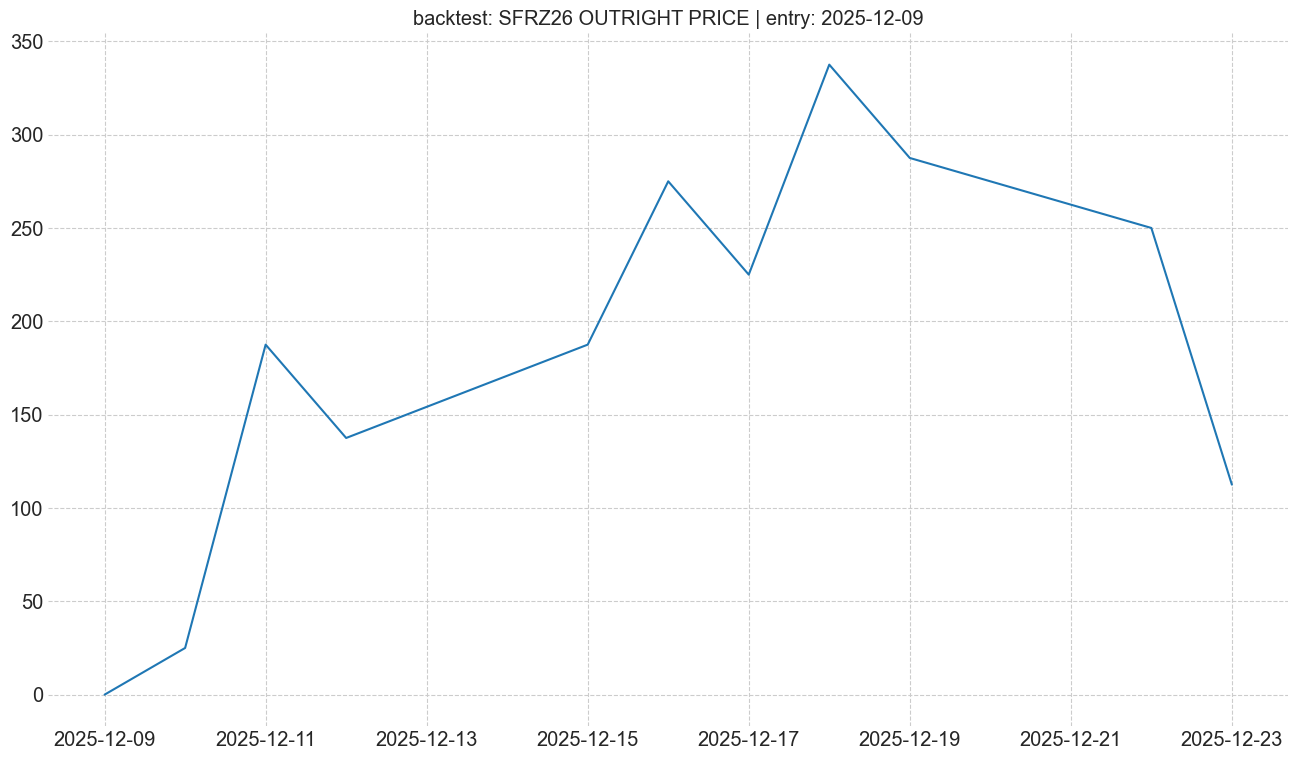

In [ ]:
trade_date = datetime.date(2025, 12, 9)

#  query = FixedRateBondQuery(cusip="ct10", structure_kwargs={"bpv": 100_000})
query = STIRFutureQuery(symbol="SFRZ26", structure_kwargs={"contracts": 100})

# entry = DateTrigger(DateTriggerRequirements(dates=[trade_date]), actions=[AddQueryAction(query=query, meta={"auto_roll": True})])
entry = DateTrigger(DateTriggerRequirements(dates=[trade_date]), actions=[AddQueryAction(query=query)])

tg = TimeGrid(
    ql_cal_date_range(
        ql_cal=ql.UnitedStates(ql.UnitedStates.GovernmentBond),
        start=trade_date,
        end=datetime.date(2025, 12, 23),
    )
)
strategy = QueryStrategy(name=f"{query.col_name()}", triggers=[entry])
bt = QueryDrivenBacktest(
    time_grid=tg,
    # mdp=swaps_mdp,
    # mdp=usts_mdp,
    mdp=stir_mdp,
    strategy=strategy,
)
bt.run()

mtm = pd.Series(bt.mtm_history).sort_index()
plt.figure()
plt.plot(mtm)
plt.title(f"backtest: {query.col_name()} | entry: {trade_date}")
plt.show()

In [14]:
for pos in bt.portfolio.iter_positions():
	print(pos)
	# print("Resolved CUSIPs:", pos.meta.get("resolved_cusips"))
    # print("Roll history:", pos.meta.get("rolls"))

ResolvedQueryPosition(package=[<rl.STIRFuture at 0x1d5f488fdd0>], weights=[-1.0], opened=Timestamp('2025-12-09 00:00:00'), source_query=STIRFutureQuery(product='STIRFUTURE', structure_id=<STIRFutureStructure.OUTRIGHT: 1>, structure_kwargs={'contracts': -100, 'symbol': 'SFRZ26'}, value_id=<STIRFutureValue.PRICE: 3>, value_ids=(), market_request={}, mdp_time_key='timestamp', name=None, tags=(), meta={}, structure=<STIRFutureStructure.OUTRIGHT: 1>, value=<STIRFutureValue.PRICE: 3>, symbol='SFRZ26', effective_date=None, maturity_date=None, is_ser=False, curve=None, value_kwargs={}, risk_weight=None), meta={'action': 'add_query', 'handler': 'stir_future', 'entry_price': 2419.75})


In [243]:
pos.package[0].notional(), pos.package[1].notional(), pos.package[2].notional()

(65769888.401836604, -55551186.48846578, 15477622.561151512)

In [12]:
usts_mdp._get_single_pricer(cusip="91282CNE7", timestamp=datetime.date(2025, 11, 28)).accured() * 100_000_000

3193681.318680586

In [8]:
from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP

sfr_mdp = STIRFutureMDP(source="BARCHART_STIRF-RL")
ts = pytz.timezone("America/Chicago").localize(datetime.datetime(2025, 12, 22, 16, 0))

res = sfr_mdp.get_data({"symbols": ["SERFFF26", "SERFFG26", "SERFFH26"], "timestamp": ts})
# res = sfr_mdp.get_data({"symbols": ["SERFFF26"], "timestamp": ts, "force_refresh": True})
# res = sfr_mdp.get_data({"symbols": ["SERFFF26"], "timestamp": "live"})
res


FETCHING SESSION TOKENS...: 100%|██████████| 7/7 [00:01<00:00,  6.07it/s]


{'SERFFF26': [RLSTIRFuturePricer(_curve='USD-SOFR-1D', _rl_stirf_id='SR1F26', _reference_date=datetime.date(2025, 12, 22), _effective_date=datetime.date(2026, 1, 2), _maturity_date=datetime.date(2026, 2, 2), _price=96.295, _rate=3.7049999999999983, _contracts=1, _notional=1000000, _meta_data={'symbol': 'SR1F26', 'price': 96.295, 'timestamp': '2025-12-22T15:59:00-06:00', 'schema': 1}),
  RLSTIRFuturePricer(_curve='USD-FEDFUNDS', _rl_stirf_id='ZQF26', _reference_date=datetime.date(2025, 12, 22), _effective_date=datetime.date(2026, 1, 2), _maturity_date=datetime.date(2026, 2, 2), _price=96.36, _rate=3.6400000000000006, _contracts=1, _notional=1000000, _meta_data={'symbol': 'ZQF26', 'price': 96.36, 'timestamp': '2025-12-22T15:59:00-06:00', 'schema': 1})],
 'SERFFG26': [RLSTIRFuturePricer(_curve='USD-SOFR-1D', _rl_stirf_id='SR1G26', _reference_date=datetime.date(2025, 12, 22), _effective_date=datetime.date(2026, 2, 2), _maturity_date=datetime.date(2026, 3, 2), _price=96.35, _rate=3.65000000

In [10]:
from Query.STIRFutures.STIRFutureQuery import STIRFutureQuery
from Query.STIRFutures.STIRFutureStructure import STIRFutureStructure
from Query.STIRFutures.STIRFutureValue import STIRFutureValue
stir_mdp = STIRFutureMDP(source="BARCHART_STIRF-RL")

In [11]:
query = STIRFutureQuery(symbol="SFRZ26", structure_kwargs={"bpv": 50_000})
pricer = stir_mdp.get_pricer(request={"symbols": [query.symbol], "timestamp": "live"})
pkg, rws = query.resolve_package(pricer_or_curve=pricer)

FETCHING SESSION TOKENS...: 100%|██████████| 2/2 [00:00<00:00,  3.81it/s]


25.0 jehrehe
2000 None


In [12]:
rws

[1.0]

In [13]:
vmap = query.build_value_map(
	pricer_or_curve=pricer,
	package=pkg,
	risk_weights=rws,
)
print(float(vmap.apply(value=STIRFutureValue.PV01)))

50000.0


In [20]:
pricer["SFRZ26"]

[RLSTIRFuturePricer(_curve='USD-SOFR-1D', _rl_stirf_id='SR3Z26', _reference_date=datetime.date(2025, 12, 24), _effective_date=datetime.date(2026, 12, 16), _maturity_date=datetime.date(2027, 3, 17), _price=96.855, _rate=3.144999999999996, _contracts=1, _notional=1000000, _meta_data={'symbol': 'SR3Z26', 'price': 96.855, 'timestamp': '2025-12-24T11:11:40.652701-06:00', 'schema': 1})]

In [9]:
pkg[-1].__dict__

{'kwargs': {'effective': datetime.datetime(2026, 1, 2, 0, 0),
  'termination': datetime.datetime(2026, 2, 2, 0, 0),
  'frequency': 'm',
  'stub': <NoInput.blank: 0>,
  'front_stub': <NoInput.blank: 0>,
  'back_stub': <NoInput.blank: 0>,
  'roll': 'som',
  'eom': False,
  'modifier': 'mf',
  'calendar': 'nyc',
  'payment_lag': 0,
  'notional': -1000000.0,
  'currency': 'usd',
  'amortization': <NoInput.blank: 0>,
  'convention': 'act360',
  'leg2_effective': datetime.datetime(2026, 1, 2, 0, 0),
  'leg2_termination': datetime.datetime(2026, 2, 2, 0, 0),
  'leg2_frequency': 'm',
  'leg2_stub': <NoInput.blank: 0>,
  'leg2_front_stub': <NoInput.blank: 0>,
  'leg2_back_stub': <NoInput.blank: 0>,
  'leg2_roll': 'som',
  'leg2_eom': False,
  'leg2_modifier': 'mf',
  'leg2_calendar': 'nyc',
  'leg2_payment_lag': 0,
  'leg2_notional': 1000000.0,
  'leg2_currency': 'usd',
  'leg2_amortization': <NoInput.blank: 0>,
  'leg2_convention': 'act360',
  'leg2_spread_compound_method': 'none_simple',
  'l

In [10]:
3.635000000000005 - 3.7049999999999983

-0.06999999999999318